# E-Commerce Customer Analytics
## Cohort Retention & RFM Segmentation

| | |
|---|---|
| **Author** | Aryan Gupta |
| **Date** | May 2026 |
| **Dataset** | Online Retail II (UCI Machine Learning Repository) |
| **Tools** | Python, Pandas, Seaborn, SQLite, Power BI |

### Objective
Analyze customer purchase behaviour across two years to identify retention trends, 
segment customers by value using RFM analysis, and surface actionable business insights 
for reducing churn and improving customer lifetime value.

## Table of Contents
1. [Data Loading](#1-data-loading)
2. [Data Cleaning](#2-data-cleaning)
3. [Feature Engineering](#3-feature-engineering)
4. [Cohort Analysis](#4-cohort-analysis)
5. [RFM Segmentation](#5-rfm-segmentation)
6. [SQL Export](#6-sql-export)
7. [Conclusions & Key Insights](#7-conclusions--key-insights)

## 1. Data Loading
Loading the Online Retail II dataset from two Excel sheets (2009-2010 and 2010-2011) and combining them into a single DataFrame.

In [1]:
import pandas as pd

In [2]:
# This will give the output in dictionary format even if the excel file has a single sheet.
# df = pd.read_excel(r"D:\Plan-A\Data-Analysis\Projects\Dataset 2\online_retail_II.xlsx", sheet_name = None)

# For normal view
df1 = pd.read_excel(r"D:\Plan-A\Data-Analysis\Projects\Dataset 2\online_retail_II.xlsx", sheet_name = "Year 2009-2010")
df1.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df2 = pd.read_excel(r"D:\Plan-A\Data-Analysis\Projects\Dataset 2\online_retail_II.xlsx", sheet_name = "Year 2010-2011")
df2.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# We will use concat for combining both the sheets.
# df = pd.concat([df1, df2]) # This will create separate indexes for both the databases 
df = pd.concat([df1, df2], ignore_index = True) # This will give us continuous indexes

In [5]:
df.to_csv("combined_online_retail", index = False) 
# Saved the combined dataset as CSV for faster loading and efficient processing during further analysis.

### Task:  
#### How many total rows and columns do we have?  
#### What is the data type of each column?  
#### How many missing values exist in each column?  

In [6]:
df.shape

(1067371, 8)

In [7]:
df.dtypes
# The data type of Customer ID is float.

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

In [8]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [9]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


## 2. Data Cleaning
Dropping null Customer IDs, removing cancellations, filtering negative/zero values, and removing duplicates to ensure data quality.

In [10]:
df = df.dropna(subset = ["Customer ID"])

In [11]:
df[["Customer ID"]].isnull().sum()

Customer ID    0
dtype: int64

In [12]:
df.shape

(824364, 8)

In [13]:
df["Customer ID"].dtype

dtype('float64')

In [14]:
# Changing the data type of Customer ID from float to int.
df["Customer ID"] = df["Customer ID"].astype(int)

In [15]:
df["Customer ID"].dtype

dtype('int64')

In [16]:
# Removing the Invoice starting with C as "C" represents cancelled orders.
if_startswith_C = df["Invoice"].astype(str).str.startswith("C")
df = df[~ if_startswith_C]

In [17]:
if_startswith_C = df["Invoice"].astype(str).str.startswith("C")
if_startswith_C.sum()

np.int64(0)

In [18]:
df.shape

(805620, 8)

### Removing Rows with negative Quantity and Price.

In [19]:
# There can be multiple ways to remove the negative values:

# 1st Method: As we created condition earlier
# condition = (df["Quantity"] >= 0) & (df["Price"] >= 0)
# df = df[condition]

# 2nd Method: Direct Method
# df = df[(df["Quantity"] >= 0) & (df["Price"] >= 0)] 

# 3rd Method: Using query()
df = df.query("Quantity >= 0 and Price >= 0")

In [20]:
(df["Quantity"] < 0).sum()

np.int64(0)

In [21]:
(df["Price"] < 0).sum()

np.int64(0)

In [22]:
(df["Quantity"] == 0).sum()

np.int64(0)

In [23]:
(df[["Price"]] == 0).sum()

Price    71
dtype: int64

In [24]:
df = df.query("Quantity > 0 and Price > 0")

In [25]:
df.shape

(805549, 8)

In [26]:
(df["Price"] == 0).sum()

np.int64(0)

### Checking and Removing Duplicate Entries

In [27]:
df.duplicated().sum()

np.int64(26124)

In [28]:
df = df.drop_duplicates()

In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
df.shape

(779425, 8)

In [31]:
df.to_csv("cleaned_online_retail.csv", index = False)

## 3. Feature Engineering
Creating new columns required for Cohort Analysis and RFM Segmentation — Total Price, Year, Month Number, Month Name, Cohort Month, Invoice Month, and Cohort Index.

In [32]:
df["Total Price"] = df["Price"] * df["Quantity"]

In [33]:
df["Total Price"]

0           83.40
1           81.00
2           81.00
3          100.80
4           30.00
            ...  
1067366     12.60
1067367     16.60
1067368     16.60
1067369     14.85
1067370     18.00
Name: Total Price, Length: 779425, dtype: float64

#### Creating New Columns: Year, Month Name, Month Number

In [34]:
df["Year"] = df["InvoiceDate"].dt.year

In [35]:
df["Month Number"] = df["InvoiceDate"].dt.month

In [36]:
df["Month Name"] = df["InvoiceDate"].dt.month_name()

In [37]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total Price,Year,Month Number,Month Name
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009,12,December
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,December
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,December
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009,12,December
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009,12,December
...,...,...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,2011,12,December
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011,12,December
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011,12,December
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,14.85,2011,12,December


In [38]:
df.shape

(779425, 12)

In [39]:
df.to_csv("cleaned_online_retail.csv", index = False)

In [40]:
# This is one of the ways in which we can create a column.
# df["Cohort Month"] = df.groupby("Customer ID")["InvoiceDate"].transform("min").dt.to_period('M')
# df.head(5)

# This is another way to do the same thing.
cohort_map = df.groupby("Customer ID")["InvoiceDate"].min().dt.to_period("M")
df["Cohort Month"] = df["Customer ID"].map(cohort_map)
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total Price,Year,Month Number,Month Name,Cohort Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009,12,December,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,December,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,December,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009,12,December,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009,12,December,2009-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,2011,12,December,2011-08
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011,12,December,2011-08
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011,12,December,2011-08
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,14.85,2011,12,December,2011-08


In [41]:
df["Invoice Month"] = df["InvoiceDate"].dt.to_period("M")
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total Price,Year,Month Number,Month Name,Cohort Month,Invoice Month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009,12,December,2009-12,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,December,2009-12,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,December,2009-12,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009,12,December,2009-12,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009,12,December,2009-12,2009-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,2011,12,December,2011-08,2011-12
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011,12,December,2011-08,2011-12
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011,12,December,2011-08,2011-12
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,14.85,2011,12,December,2011-08,2011-12


In [42]:
# This is one way:
# df["Cohort Index"] = df["Invoice Month"].astype(int) - df["Cohort Month"].astype(int)

# Second Method:
df["Cohort Index"] = (df["Invoice Month"] - df["Cohort Month"]).apply(lambda x: x.n)
# apply(lambda x: x.n) means - Go through each row one by one and give me only the number part.
# Or we can say that we extracted the numeric part from every row.
df


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total Price,Year,Month Number,Month Name,Cohort Month,Invoice Month,Cohort Index
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009,12,December,2009-12,2009-12,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,December,2009-12,2009-12,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,December,2009-12,2009-12,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009,12,December,2009-12,2009-12,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009,12,December,2009-12,2009-12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60,2011,12,December,2011-08,2011-12,4
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011,12,December,2011-08,2011-12,4
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011,12,December,2011-08,2011-12,4
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680,France,14.85,2011,12,December,2011-08,2011-12,4


In [43]:
df['Cohort Month'] = df['Cohort Month'].astype(str)

In [44]:
df.to_csv("cleaned_online_retail.csv", index=False)

## 4. Cohort Analysis
Grouping customers by their first purchase month and tracking retention across subsequent months to identify retention patterns.

In [45]:
# There are two ways to build matrix.
# 1. Use groupby() + reset_index() + pivot()
# cohort_data = df.groupby(["Cohort Month", "Cohort Index"])["Customer ID"].nunique().reset_index()
# cohort_table = cohort_data.pivot(
#     index = "Cohort Month",
#     columns = "Cohort Index",
#     values = "Customer ID"
# )
# cohort_table

# 2. Directly using pivot table
cohort_table = df.pivot_table(
    index = "Cohort Month",
    columns = "Cohort Index",
    values = "Customer ID",
    aggfunc = "nunique"
)
cohort_table

Cohort Index,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Cohort Month,,,,,,,,,,,,,,,,,,,,,
2009-12,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,...,289.0,251.0,289.0,270.0,248.0,244.0,301.0,291.0,389.0,188.0
2010-01,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,...,58.0,90.0,76.0,71.0,75.0,93.0,74.0,94.0,22.0,NaN
2010-02,374.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,...,75.0,60.0,61.0,54.0,86.0,86.0,61.0,22.0,NaN,NaN
2010-03,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,48.0,...,75.0,77.0,69.0,78.0,89.0,94.0,35.0,NaN,NaN,NaN
2010-04,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,31.0,32.0,...,46.0,41.0,44.0,53.0,66.0,17.0,NaN,NaN,NaN,NaN
2010-05,254.0,40.0,43.0,44.0,45.0,65.0,54.0,32.0,15.0,21.0,...,32.0,35.0,42.0,39.0,12.0,NaN,NaN,NaN,NaN,NaN
2010-06,270.0,47.0,51.0,55.0,62.0,77.0,34.0,24.0,22.0,32.0,...,33.0,36.0,55.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,186.0,29.0,34.0,55.0,54.0,26.0,21.0,27.0,27.0,21.0,...,32.0,44.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,162.0,33.0,48.0,52.0,28.0,19.0,16.0,20.0,22.0,21.0,...,32.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', None)
# cohort_table

In [84]:
# retention_table = (cohort_table/cohort_table[0]) * 100 # This will give NaN as output
# retention_table

# This is one way to do the division
# retention_table = cohort_table.divide(cohort_table[0], axis = 0) * 100
# retention_table

# This is another way to do the division
retention_table = cohort_table.divide(cohort_table.iloc[:,0], axis = 0) * 100
retention_table = retention_table.round(2)
retention_table

Cohort Index,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Cohort Month,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,35.29,33.40,42.51,38.01,35.92,37.70,34.24,33.61,36.23,...,30.26,26.28,30.26,28.27,25.97,25.55,31.52,30.47,40.73,19.69
2010-01,100.0,20.63,31.07,30.55,26.37,30.03,25.85,22.98,27.94,31.85,...,15.14,23.50,19.84,18.54,19.58,24.28,19.32,24.54,5.74,NaN
2010-02,100.0,23.80,22.46,29.14,24.60,20.05,19.25,28.61,25.40,27.54,...,20.05,16.04,16.31,14.44,22.99,22.99,16.31,5.88,NaN,NaN
2010-03,100.0,18.96,23.02,24.15,23.25,20.32,24.60,30.25,27.54,10.84,...,16.93,17.38,15.58,17.61,20.09,21.22,7.90,NaN,NaN,NaN
2010-04,100.0,19.39,19.39,16.33,18.37,22.45,27.55,26.19,10.54,10.88,...,15.65,13.95,14.97,18.03,22.45,5.78,NaN,NaN,NaN,NaN
2010-05,100.0,15.75,16.93,17.32,17.72,25.59,21.26,12.60,5.91,8.27,...,12.60,13.78,16.54,15.35,4.72,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,17.41,18.89,20.37,22.96,28.52,12.59,8.89,8.15,11.85,...,12.22,13.33,20.37,5.19,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,15.59,18.28,29.57,29.03,13.98,11.29,14.52,14.52,11.29,...,17.20,23.66,8.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,20.37,29.63,32.10,17.28,11.73,9.88,12.35,13.58,12.96,...,19.75,6.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Cohort Index', ylabel='Cohort Month'>

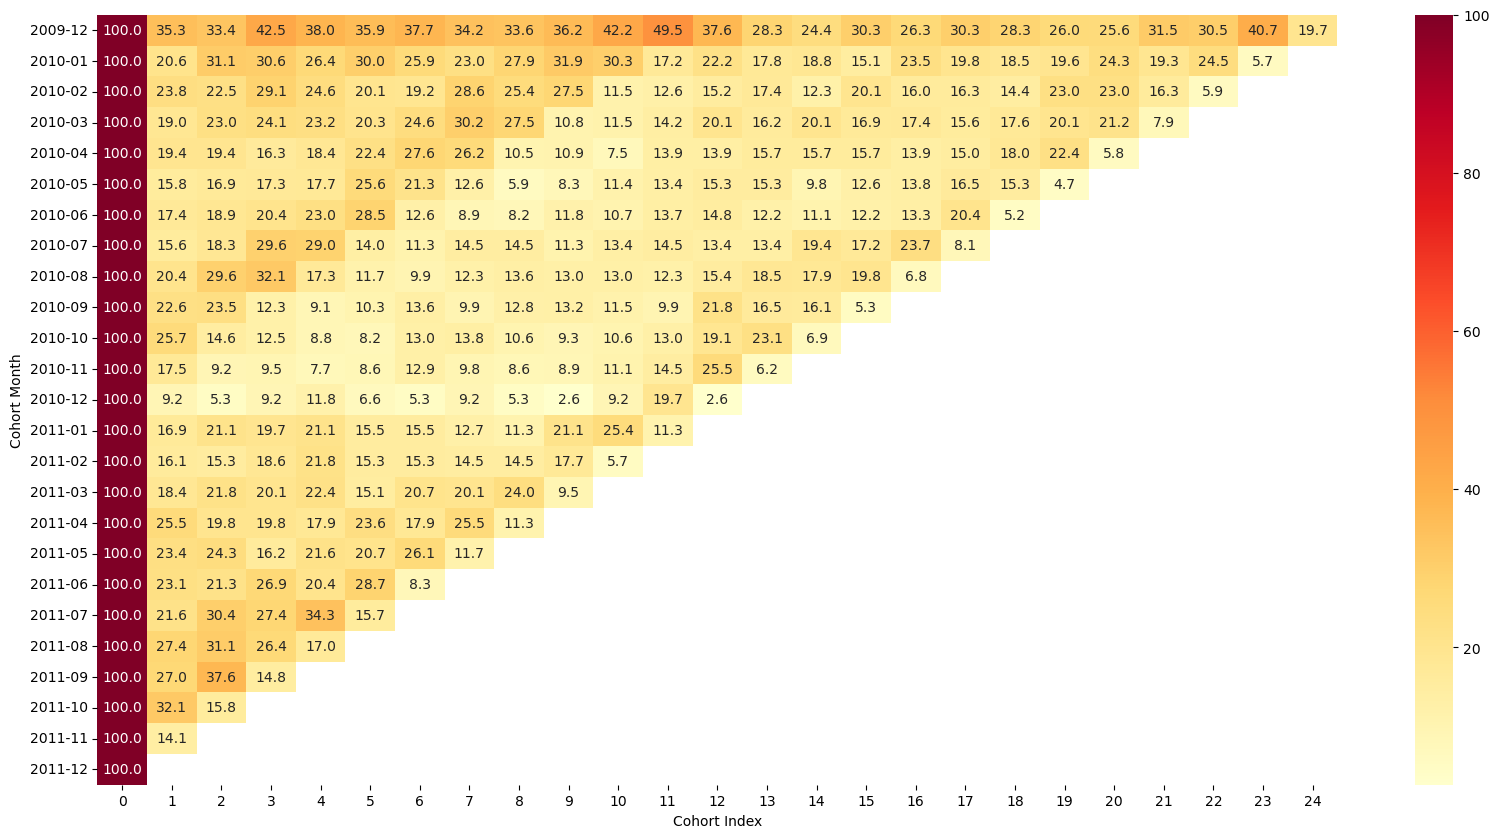

In [49]:
plt.figure(figsize=(20,10))
sns.heatmap(
    retention_table,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

### 📊 Cohort Analysis — Key Insights
- **50%+ customers** never return after their first purchase: retention is the core business problem
- **Dec 2009 cohort** shows the strongest retention across all time periods
- **12-month spikes** visible in Dec cohorts: indicating seasonal/holiday buyers returning annually
- **2010-12 cohort** has abnormally low retention: likely one-time holiday shoppers

## 5. RFM Segmentation
Scoring customers on Recency, Frequency, and Monetary value to segment them into actionable business categories.

In [50]:
reference_date = (df["InvoiceDate"].max()) + pd.Timedelta(days = 1)
reference_date

Timestamp('2011-12-10 12:50:00')

In [51]:
recency = (
    reference_date - df.groupby("Customer ID")["InvoiceDate"].max()
).dt.days.to_frame()
recency

,InvoiceDate
Customer ID,
12346,326
12347,2
12348,75
12349,19
12350,310
...,...
18283,4
18284,432
18285,661


In [52]:
frequency = df.groupby("Customer ID")[["Invoice"]].nunique()
frequency

,Invoice
Customer ID,
12346,12
12347,8
12348,5
12349,4
12350,1
...,...
18283,22
18284,1
18285,1


In [53]:
monetary = df.groupby("Customer ID")[["Total Price"]].sum()
monetary

,Total Price
Customer ID,
12346,77556.46
12347,4921.53
12348,2019.40
12349,4428.69
12350,334.40
...,...
18283,2664.90
18284,461.68
18285,427.00


In [54]:
rfm = pd.concat([recency, frequency, monetary], axis = 1)
rfm.columns = ["Recency", "Frequency", "Monetary"] # For renaming the columns
rfm

,Recency,Frequency,Monetary
Customer ID,,,
12346,326,12,77556.46
12347,2,8,4921.53
12348,75,5,2019.40
12349,19,4,4428.69
12350,310,1,334.40
...,...,...,...
18283,4,22,2664.90
18284,432,1,461.68
18285,661,1,427.00


In [55]:
# The above process required 4 steps but this can also be done in single step.
# rfm = df.groupby("Customer ID").agg({
#     "InvoiceDate": "max",
#     "Invoice": "nunique",
#     "Total Price": "sum"
# })
# rfm["InvoiceDate"] = (
#     reference_date - rfm["InvoiceDate"]
# ).dt.days
# rfm.columns = ["Recency", "Frequency", "Monetary"] # For renaming the columns
# rfm

In [56]:
rfm["Recency_Score"] = pd.qcut(
    rfm["Recency"], 
    5, 
    labels = [5,4,3,2,1]
)

rfm["Frequency_Score"] = pd.qcut(
    # rank(method="first") is used before qcut() 
    # to handle duplicate values properly.
    # It gives unique ordering to repeated values,
    # allowing qcut() to create equal quantile groups without errors.
    rfm["Frequency"].rank(method="first"), 
    5, 
    labels = [1,2,3,4,5],
    duplicates = "drop"
    # duplicates="drop" removes duplicate bin edges
    # when qcut() cannot create perfectly unique groups.
)

rfm["Monetary_Score"] = pd.qcut(
    rfm["Monetary"], 
    5, 
    labels = [1,2,3,4,5]
)
rfm

,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score
Customer ID,,,,,,
12346,326,12,77556.46,2,5,5
12347,2,8,4921.53,5,4,5
12348,75,5,2019.40,3,4,4
12349,19,4,4428.69,5,3,5
12350,310,1,334.40,2,1,2
...,...,...,...,...,...,...
18283,4,22,2664.90,5,5,4
18284,432,1,461.68,1,2,2
18285,661,1,427.00,1,2,2


In [57]:
rfm["RFM Score"] = (
    rfm["Recency_Score"].astype(str) +
    rfm["Frequency_Score"].astype(str) +
    rfm["Monetary_Score"].astype(str) 
)
rfm

,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score,RFM Score
Customer ID,,,,,,,
12346,326,12,77556.46,2,5,5,255
12347,2,8,4921.53,5,4,5,545
12348,75,5,2019.40,3,4,4,344
12349,19,4,4428.69,5,3,5,535
12350,310,1,334.40,2,1,2,212
...,...,...,...,...,...,...,...
18283,4,22,2664.90,5,5,4,554
18284,432,1,461.68,1,2,2,122
18285,661,1,427.00,1,2,2,122


In [58]:
# First we will import numpy - because later we will have to use select() function which is available in numpy library.
# np.select() -> It basically assigns the values based on multiple conditions.
# if -> elif -> elif -> else
# if customer is Champion:
#     assign "Champion"
# elif customer is At Risk:
#     assign "At Risk"
# else:
#     assign "Others" -> So, it works in this way
import numpy as np


# First let us initialize the variables so that it will be easy to write the conditions.
R = rfm["Recency_Score"]
F = rfm["Frequency_Score"]

# Now, we will write the conditions 
conditions = [
    (R >= 4) & (F >= 4),     # Champions
    (R == 3) & (F == 3),     # Needs Attention
    (R >= 2) & (F >= 3),     # Loyal Customers
    (R >= 4) & (F <= 1),     # Recent Customers
    (R >= 3) & (F <= 2),     # Potential Loyalists
    (R <= 2) & (F >= 2),     # At Risk
    (R <= 2) & (F <= 2),     # Lost
]

# Now, we will write the segments
segments = [
    "Champions",
    "Needs Attention",
    "Loyal Customers",
    "Recent Customers",
    "Potential Loyalists",
    "At Risk",
    "Lost"
]

# Customer Segmentation
rfm["Segment"] = np.select(
    conditions,
    segments,
    default = "Others"
)

rfm

,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score,RFM Score,Segment
Customer ID,,,,,,,,
12346,326,12,77556.46,2,5,5,255,Champions
12347,2,8,4921.53,5,4,5,545,At Risk
12348,75,5,2019.40,3,4,4,344,Champions
12349,19,4,4428.69,5,3,5,535,At Risk
12350,310,1,334.40,2,1,2,212,Recent Customers
...,...,...,...,...,...,...,...,...
18283,4,22,2664.90,5,5,4,554,At Risk
18284,432,1,461.68,1,2,2,122,Potential Loyalists
18285,661,1,427.00,1,2,2,122,Potential Loyalists


In [59]:
rfm["Segment"].value_counts().to_frame()

,count
Segment,
At Risk,1551
Champions,1514
Recent Customers,1122
Potential Loyalists,900
Loyal Customers,471
Needs Attention,266
Lost,54


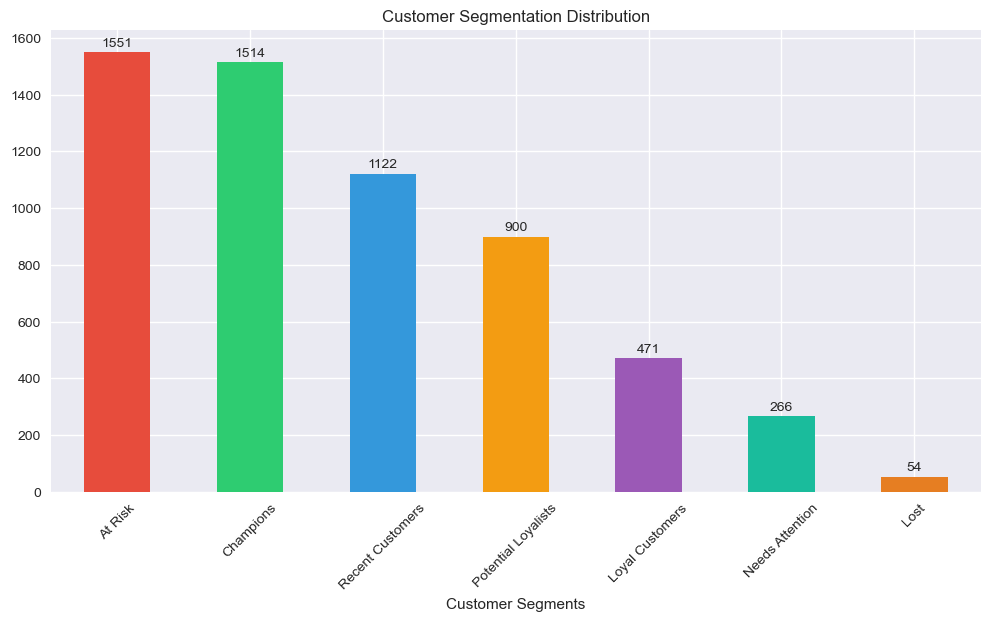

In [60]:
plt.style.use("seaborn-v0_8")
segment_counts = rfm["Segment"].value_counts()
plt.figure(figsize=(12,6))                            # Setting the size of the graph
segment_counts.plot(
    kind = "bar",
    color=['#e74c3c','#2ecc71','#3498db','#f39c12','#9b59b6','#1abc9c','#e67e22']
)                    
plt.title("Customer Segmentation Distribution")      # Adding title of the chart
plt.xlabel("Customer Segments")                      # Adding x-label
plt.xticks(rotation = 45)                            # Rotating labels
for i, v in enumerate(segment_counts):
    plt.text(i, v + 20, str(v), ha="center", fontsize=10)
plt.show()

### 📊 RFM Segmentation — Key Insights
- **At Risk (1,551)** is the largest segment — highest priority for re-engagement campaigns
- **At Risk customers have avg revenue of 6,271** — nearly double Champions (3,894)
- **Champions (1,514)** represent 26% of customers — must be protected with loyalty programs
- **1,122 Recent Customers** — converting even 30% to loyal would significantly grow retention

In [61]:
segment_analysis = rfm.groupby("Segment")[[
    "Recency",
    "Frequency",
    "Monetary"
]].mean().round(2)
segment_analysis

,Recency,Frequency,Monetary
Segment,,,
At Risk,16.48,11.63,6271.42
Champions,131.69,9.31,3894.23
Lost,10.50,1.00,359.75
Loyal Customers,387.75,2.97,1058.79
Needs Attention,113.36,3.15,1273.68
Potential Loyalists,369.16,1.58,546.60
Recent Customers,368.01,1.00,359.27


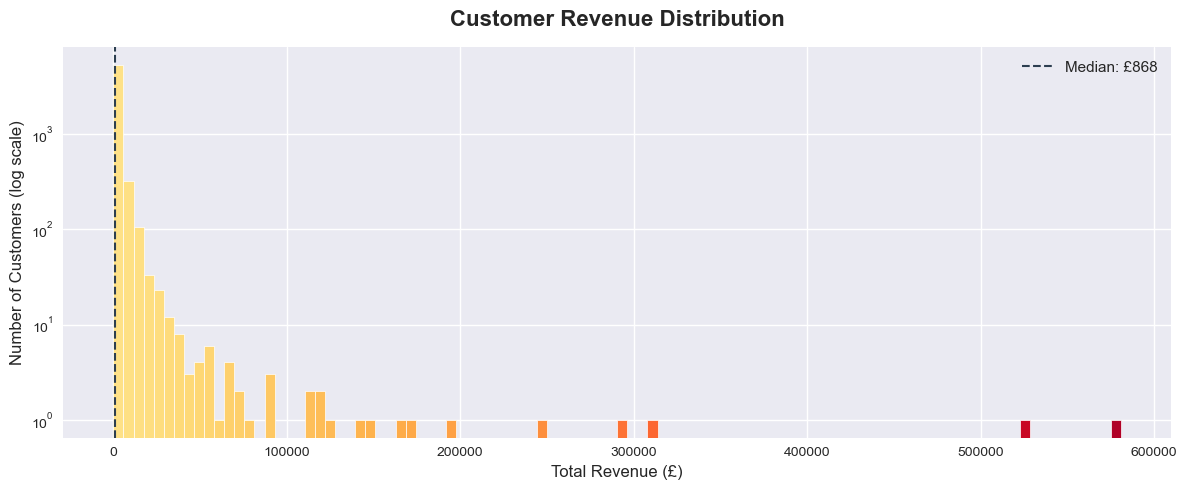

In [79]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12,5))
n, bins, patches = ax.hist(rfm['Monetary'], bins=100, edgecolor='white', linewidth=0.5)

# Color gradient from light to dark blue
colors = plt.cm.YlOrRd(np.linspace(0.2, 0.9, len(patches)))
for patch, color in zip(patches, colors):
    patch.set_facecolor(color)

ax.set_yscale('log')
ax.set_title('Customer Revenue Distribution', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (£)', fontsize=12)
ax.set_ylabel('Number of Customers (log scale)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axvline(rfm['Monetary'].median(), color='#2c3e50', linestyle='--', linewidth=1.5, label=f"Median: £{rfm['Monetary'].median():.0f}")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

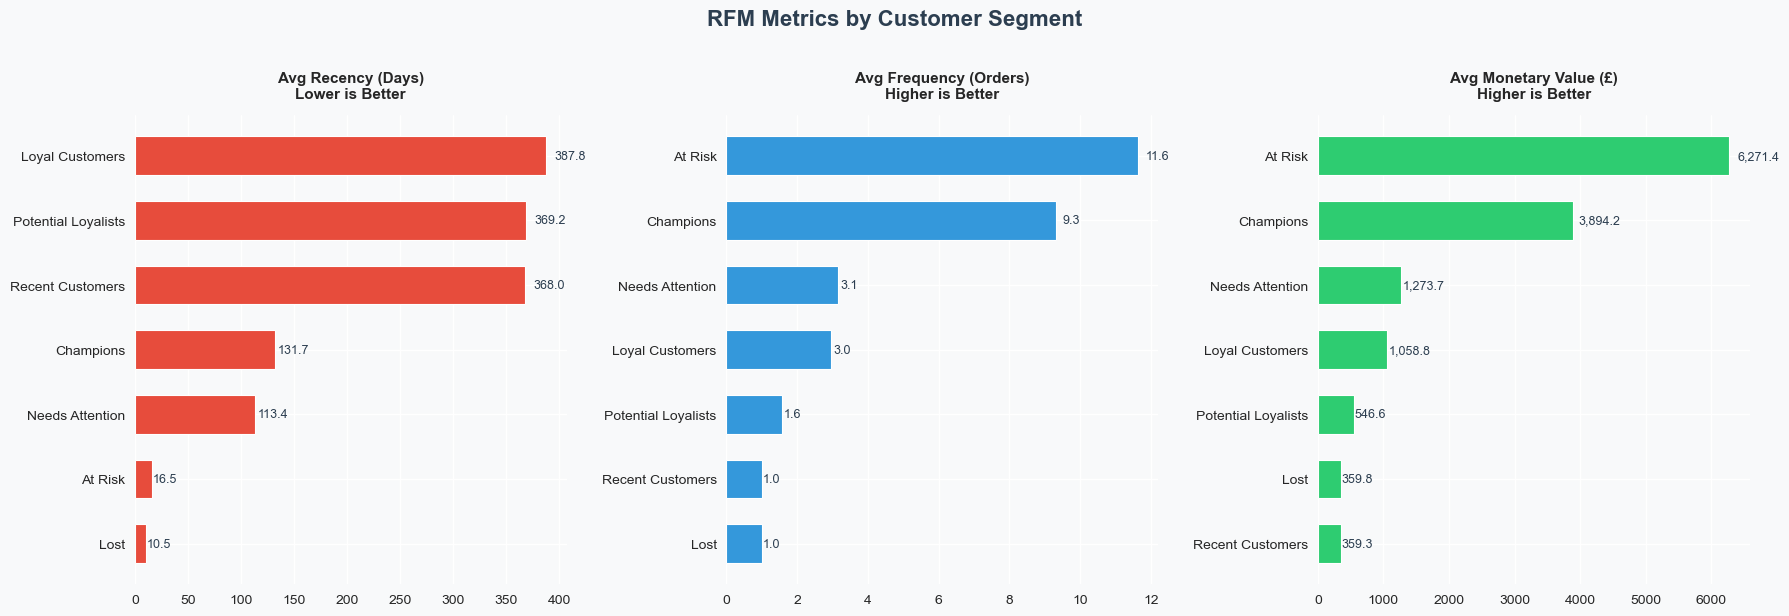

In [83]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#f8f9fa')

metrics = ['Recency', 'Frequency', 'Monetary']
colors = ['#E74C3C', '#3498DB', '#2ECC71']
titles = ['Avg Recency (Days)\nLower is Better', 'Avg Frequency (Orders)\nHigher is Better', 'Avg Monetary Value (£)\nHigher is Better']

for i, (metric, color, title) in enumerate(zip(metrics, colors, titles)):
    data = segment_analysis[metric].sort_values(ascending=True)
    bars = axes[i].barh(data.index, data.values, color=color, edgecolor='white', linewidth=0.8, height=0.6)
    axes[i].set_title(title, fontsize=11, fontweight='bold', pad=12)
    axes[i].set_facecolor('#f8f9fa')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_visible(False)
    axes[i].tick_params(left=False)
    
    for bar, val in zip(bars, data.values):
        axes[i].text(bar.get_width() * 1.02, bar.get_y() + bar.get_height()/2,
                    f'{val:,.1f}', va='center', fontsize=9, color='#2c3e50')

plt.suptitle('RFM Metrics by Customer Segment', fontsize=16, fontweight='bold', y=1.02, color='#2c3e50')
plt.tight_layout()
plt.show()

## 6. SQL Export
Exporting cleaned transaction data and RFM segments to a SQLite database for SQL-based analysis.

In [63]:
import sqlite3

In [64]:
# Creating a database connection
conn = sqlite3.connect("retail_analytics.db")

In [65]:
df["Cohort Month"] = df["Cohort Month"].astype(str)
df["Invoice Month"] = df["Invoice Month"].astype(str)
df["InvoiceDate"] = df["InvoiceDate"].astype(str)

In [66]:
df.to_sql( 
    "transactions", 
    conn, 
    if_exists="replace", 
    index=False 
)

779425

In [67]:
rfm.to_sql("rfm_segments", conn, if_exists="replace", index=True)

5878

In [68]:
conn.close()

In [70]:
rfm.to_csv("rfm_segments.csv", index=True)

## 7. Conclusions & Key Insights

### Business Questions Answered

**1. Are we retaining customers over time?**
No. Over 50% of customers never return after their first purchase. Retention is the core business problem.

**2. Who are our most and least valuable customers?**
- **Champions (1,514)** — high recency, high frequency, must be protected
- **At Risk (1,551)** — highest avg revenue (£6,271) despite low engagement — highest priority for re-engagement

**3. Which segments are at highest churn risk?**
- At Risk segment is the largest and most valuable — immediate action required
- Lost segment (54 customers) — too late to recover, focus resources on At Risk instead

### Key Findings
- 🔴 **50%+ customers lost after first purchase** — retention is broken at the acquisition-to-repeat stage
- 🔴 **At Risk customers generate £6,271 avg revenue** — nearly double Champions (£3,894)
- 🟡 **December cohorts show 12-month spikes** — seasonal buyers misclassified as churned
- 🟡 **1,551 at-risk customers** represent the highest business priority
- 🌍 **United Kingdom dominates at £14.3M** — geographic concentration risk